# Faze 3: Labeling -- prirazeni skladovych trid
Vizualizace rozlozeni skladovych trid prirazenych pravidlovym pristupem.

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

_PROJECT_ROOT = (
    Path(os.path.abspath("")).parent
    if Path(os.path.abspath("")).name == "notebooks"
    else Path(os.path.abspath(""))
)
os.chdir(_PROJECT_ROOT)
sys.path.insert(0, str(_PROJECT_ROOT))

sns.set_theme(style="whitegrid", palette="colorblind")

RESULTS_DIR = Path("results/phase3_labeling")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"CWD: {os.getcwd()}")
print("Setup OK")

CWD: C:\Users\kosar\Desktop\bakalarka_git\bakalarka
Setup OK


In [2]:
df = pd.read_csv("data/processed/products_labeled.csv")
print(f"Dataset: {df.shape[0]:,} produktu x {df.shape[1]} sloupcu")
print(f"\nRozlozeni trid:")
print(df["storage_class"].value_counts().to_string())

Dataset: 32,949 produktu x 25 sloupcu

Rozlozeni trid:
storage_class
shelf_picking     13087
front_zone_bin     9341
special_zone       5360
floor_block        2651
pallet_rack        2510


## 1. Rozlozeni trid

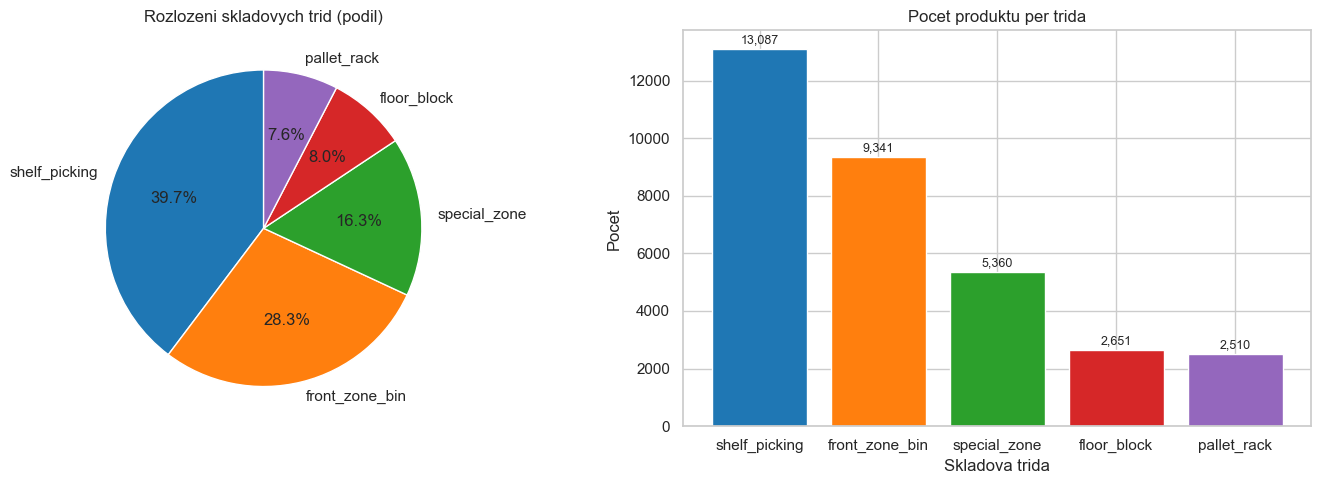

Ulozeno: results/labeling_class_distribution.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dist = df["storage_class"].value_counts()
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

# Pie chart
axes[0].pie(
    dist.values,
    labels=dist.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
)
axes[0].set_title("Rozlozeni skladovych trid (podil)")

# Bar chart
axes[1].bar(dist.index, dist.values, color=colors)
axes[1].set_title("Pocet produktu per trida")
axes[1].set_ylabel("Pocet")
axes[1].set_xlabel("Skladova trida")
for i, (cls, cnt) in enumerate(dist.items()):
    axes[1].text(i, cnt + 200, f"{cnt:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "labeling_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Ulozeno: results/labeling_class_distribution.png")

## 2. Scatter plot -- sanity check

Scatter plot hmotnost vs. objem obarveny tridami slouzi jako vizualni overeni,
ze pravidla prirazuji logicke tridy. Pokud se barvy michaji (barevny salat),
je to dukaz, ze problem je vicerozmerny a jednoducha 2D pravidla nestaci --
argument pro AI modely ve Fazi 5.

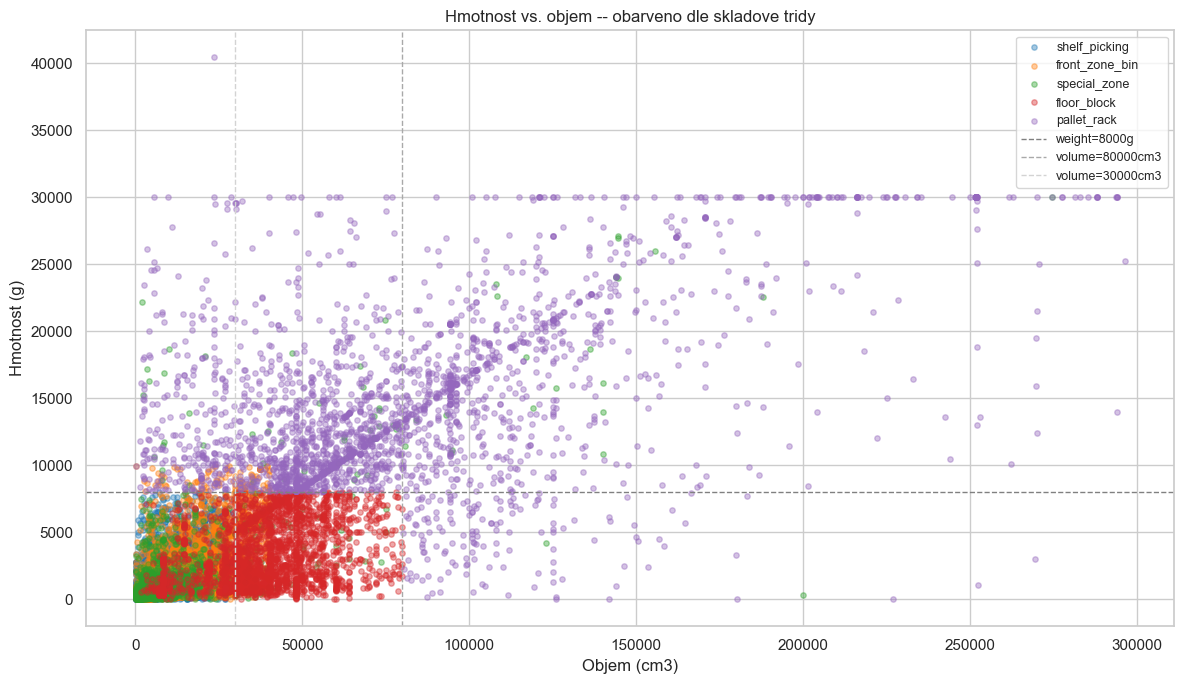

Ulozeno: results/labeling_scatter_weight_volume.png


In [4]:
fig, ax = plt.subplots(figsize=(12, 7))

class_colors = {
    "shelf_picking": "#1f77b4",
    "front_zone_bin": "#ff7f0e",
    "special_zone": "#2ca02c",
    "floor_block": "#d62728",
    "pallet_rack": "#9467bd",
}

for cls, color in class_colors.items():
    mask = df["storage_class"] == cls
    ax.scatter(
        df.loc[mask, "volume_cm3"],
        df.loc[mask, "product_weight_g"],
        c=color,
        label=cls,
        alpha=0.4,
        s=15,
    )

ax.axhline(y=8000, color="gray", linestyle="--", linewidth=1, label="weight=8000g")
ax.axvline(x=80000, color="darkgray", linestyle="--", linewidth=1, label="volume=80000cm3")
ax.axvline(x=30000, color="lightgray", linestyle="--", linewidth=1, label="volume=30000cm3")

ax.set_xlabel("Objem (cm3)")
ax.set_ylabel("Hmotnost (g)")
ax.set_title("Hmotnost vs. objem -- obarveno dle skladove tridy")
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "labeling_scatter_weight_volume.png", dpi=150, bbox_inches="tight")
plt.show()
print("Ulozeno: results/labeling_scatter_weight_volume.png")

## 3. Fyzicke atributy per trida

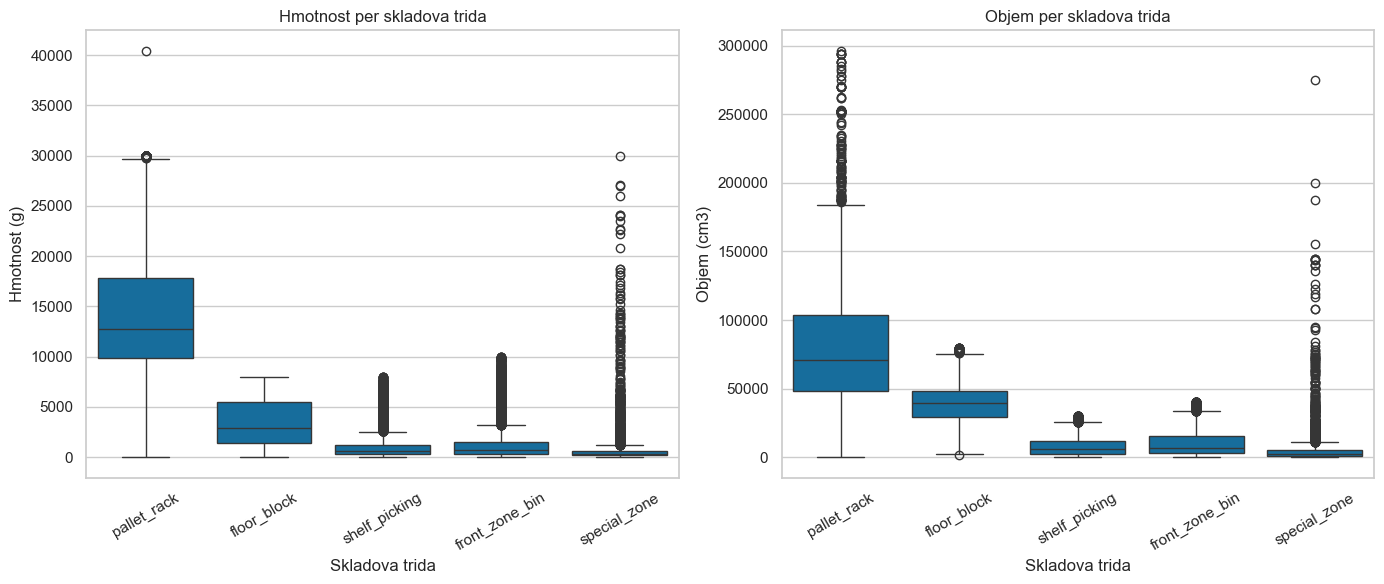

Ulozeno: results/labeling_physical_per_class.png


In [5]:
class_order = ["pallet_rack", "floor_block", "shelf_picking", "front_zone_bin", "special_zone"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(
    data=df,
    x="storage_class",
    y="product_weight_g",
    order=class_order,
    ax=axes[0],
)
axes[0].set_title("Hmotnost per skladova trida")
axes[0].set_xlabel("Skladova trida")
axes[0].set_ylabel("Hmotnost (g)")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(
    data=df,
    x="storage_class",
    y="volume_cm3",
    order=class_order,
    ax=axes[1],
)
axes[1].set_title("Objem per skladova trida")
axes[1].set_xlabel("Skladova trida")
axes[1].set_ylabel("Objem (cm3)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "labeling_physical_per_class.png", dpi=150, bbox_inches="tight")
plt.show()
print("Ulozeno: results/labeling_physical_per_class.png")

## 4. Kategorie vs. trida

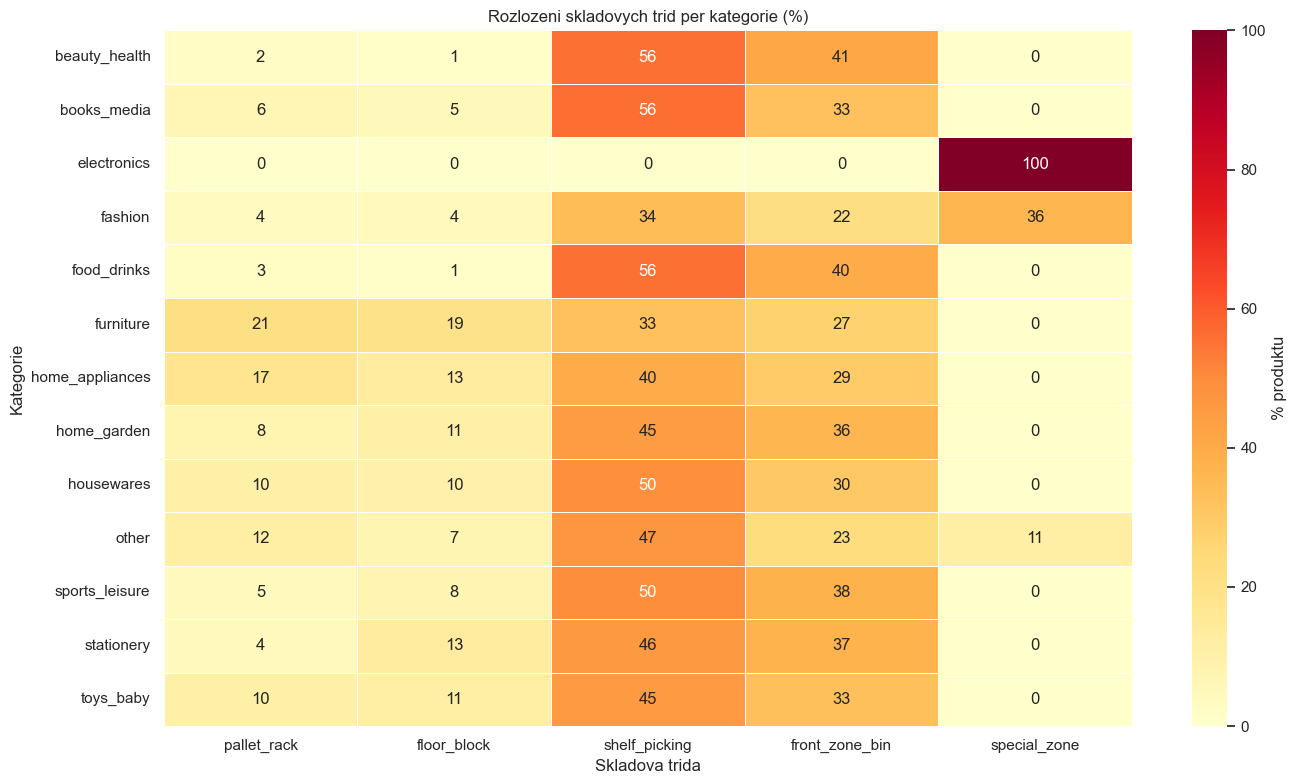

Ulozeno: results/labeling_category_vs_class.png


In [6]:
class_order = ["pallet_rack", "floor_block", "shelf_picking", "front_zone_bin", "special_zone"]

ct = pd.crosstab(df["category_group"], df["storage_class"], normalize="index") * 100
ct = ct[class_order]

fig, ax = plt.subplots(figsize=(14, max(8, len(ct) * 0.35)))
sns.heatmap(
    ct,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "% produktu"},
)
ax.set_title("Rozlozeni skladovych trid per kategorie (%)")
ax.set_xlabel("Skladova trida")
ax.set_ylabel("Kategorie")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "labeling_category_vs_class.png", dpi=150, bbox_inches="tight")
plt.show()
print("Ulozeno: results/labeling_category_vs_class.png")

## 5. Obratkovost per trida

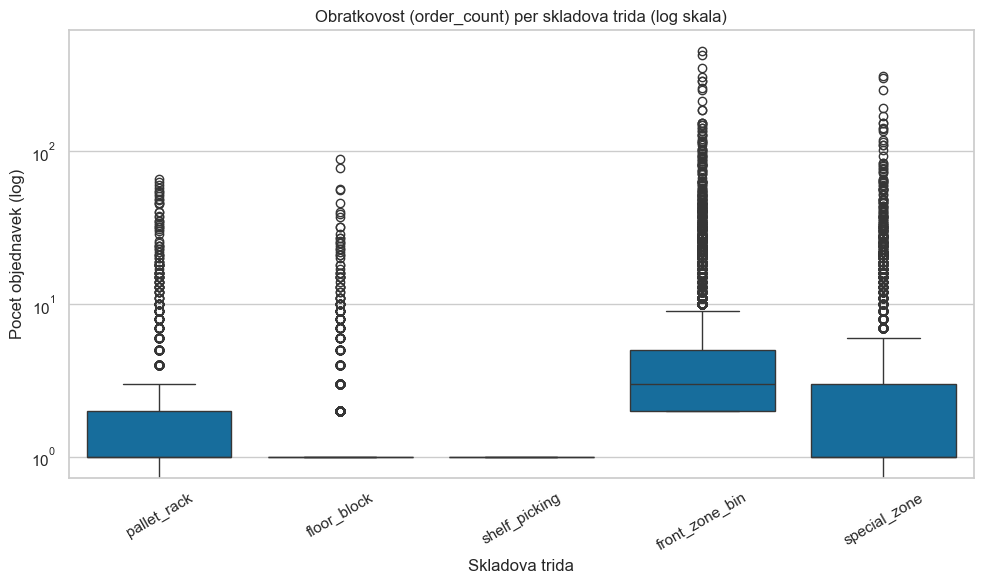

Ulozeno: results/labeling_turnover_per_class.png


In [7]:
class_order = ["pallet_rack", "floor_block", "shelf_picking", "front_zone_bin", "special_zone"]

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="storage_class",
    y="order_count",
    order=class_order,
    ax=ax,
)
ax.set_yscale("log")
ax.set_title("Obratkovost (order_count) per skladova trida (log skala)")
ax.set_xlabel("Skladova trida")
ax.set_ylabel("Pocet objednavek (log)")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "labeling_turnover_per_class.png", dpi=150, bbox_inches="tight")
plt.show()
print("Ulozeno: results/labeling_turnover_per_class.png")

## 6. Shrnuti

In [8]:
print("SHRNUTI FAZE 3: Labeling")
print("=" * 60)
dist = df["storage_class"].value_counts()
for cls, cnt in dist.items():
    print(f"  {cls}: {cnt:,} ({cnt/len(df)*100:.1f}%)")
print(f"\nCelkem: {len(df):,} produktu")
print(f"Vystup: data/processed/products_labeled.csv")

SHRNUTI FAZE 3: Labeling
  shelf_picking: 13,087 (39.7%)
  front_zone_bin: 9,341 (28.3%)
  special_zone: 5,360 (16.3%)
  floor_block: 2,651 (8.0%)
  pallet_rack: 2,510 (7.6%)

Celkem: 32,949 produktu
Vystup: data/processed/products_labeled.csv
